In [31]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [32]:
import os
import sys
import time

import numpy as np
import matplotlib.pyplot as plt

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import tensorflow as tf

from tensorflow.keras import Input
from tensorflow.keras.callbacks import EarlyStopping, TerminateOnNaN
from tensorflow.keras.optimizers import Adam

sys.path.append(os.path.join(os.getcwd(), "scripts"))

from scripts.utils import Config, setup_logging
from scripts.utils.tf.dataloaders import *
from scripts.utils.tf.plots import plot_histogram, plot_metrics, plot_predictions
from scripts.utils.tf.callbacks import TimedLoggingCallback, WarmupLearningRate

from scripts.attn_alm import alm_model

In [33]:
logger = setup_logging("alm_model")

In [34]:
s = Config(
    [
        "settings/l500_n128.json",
        "--nsims",
        "200",
        "--narray",
        "500",
        "--disable_lensing",
        # "--noise",
        # "--save_settings",
    ]
)

# s = Config(["settings/l500_1000.json"])

MAX_EPOCHS = 100
BATCH_SIZE = 8

# just some info for the model name
timestamp = int(time.time())
model_settings = {
    # "dropout_rate": 0.1,
    "name": f"tester",
}

data_loader_args = {
    "shuffle": True,
    "shuffle_buffer": 1000,
    "seed": None,
    "batch_size": BATCH_SIZE,
    "cache": True,
}

# additional metrics we are intrested in
metrics = ["mean_absolute_error"]

06-Mar-24 13:25:06 - scripts.utils.config - INFO - Loading settings from file settings/l500_n128.json
06-Mar-24 13:25:06 - scripts.utils.config - INFO - Running with settings: 
{
  "cosmo_params": {
    "H0": 67.5,
    "r": 0,
    "As": 2.13e-09,
    "ns": 0.9624,
    "pivot_scalar": 0.05,
    "ombh2": 0.02233,
    "omch2": 0.1198,
    "mnu": 0.06,
    "tau": 0.0561,
    "TCMB": 2.7255,
    "max_l": 1000,
    "lmax": 500,
    "lens_potential_accuracy": 2,
    "DoLateRadTruncation": false,
    "AccuracyBoost": 2.0,
    "lSampleBoost": 2.0,
    "lAccuracyBoost": 2.0
  },
  "nsims": 200,
  "narray": 500,
  "npatches": 10,
  "fnl_range": [
    -1000,
    1000
  ],
  "nside": 128,
  "lensing": false,
  "noise": false,
  "noise_scale_tt": 1,
  "noise_scale_ee": 1.41421,
  "noise_scale_te": 0,
  "beam_width": 1.4
}
06-Mar-24 13:25:06 - scripts.utils.config - INFO - Running SLURM job 154313
06-Mar-24 13:25:06 - scripts.utils.config - INFO - Base name: l500_n128_ul_T_100000


In [35]:
# data_loader = TFDSLoader(s.alm_file, **data_loader_args)
data_loader = AlmLoaderV2(s.alm_file, **data_loader_args)
train_dataset, test_dataset, val_dataset = data_loader.get_split(0.8, 0.1, 0.1)

06-Mar-24 13:25:06 - AlmLoaderV2 - INFO - Loaded data/alms/l500_n128_ul_T_100000.alms.hdf5 with 100000 sims, and 1 pols
06-Mar-24 13:25:06 - AlmLoaderV2 - INFO - Dataset sizes: Training 80000, Testing 10000, Validation 10000


In [36]:
class CustomSchedule(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, d_model, warmup_steps=4000):
        super(CustomSchedule, self).__init__()
        self.d_model = d_model
        self.d_model = tf.cast(self.d_model, tf.float32)
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        arg1 = tf.math.rsqrt(step)
        arg2 = step * (self.warmup_steps**-1.5)
        return tf.math.rsqrt(self.d_model) * tf.math.minimum(arg1, arg2)

# steps_per_epoch = data_loader.length // BATCH_SIZE
learning_rate = CustomSchedule(data_loader.shape[-1]) #, warmup_steps=5 * steps_per_epoch)

# plt.loglog(learning_rate(tf.range(40000, dtype=tf.float32)))
# plt.ylabel('Learning Rate')
# plt.xlabel('Train Step')
# plt.show()

In [37]:
# learning_rate = WarmupLearningRate(
#     warmup_learning_rate=1e-4,  # start small
#     warmup_steps=10000,
#     warmup_scale=1.5,
#     warmup_scale_steps=100,
#     warmed_learning_rate="auto",
#     decay_steps=1e3,
#     decay_rate=0.95,
#     staircase=True,
# )

# plt.loglog([learning_rate(x) for x in np.arange(40000)])
# plt.ylabel('Learning Rate')
# plt.xlabel('Train Step')
# plt.show()

In [38]:
strategy = tf.distribute.MirroredStrategy()
with strategy.scope():
    opt = Adam(learning_rate, beta_1=0.9, beta_2=0.98, epsilon=1e-9)
    model = alm_model(Input(data_loader.shape), **model_settings)
    model.compile(optimizer=opt, loss=tf.keras.losses.mse, metrics=metrics)

In [39]:
model.summary()

Model: "tester"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_3 (InputLayer)        [(None, 1000, 500)]          0         []                            
                                                                                                  
 multi_head_attention_6 (Mu  (None, 1000, 500)            4006500   ['input_3[0][0]',             
 ltiHeadAttention)                                                   'input_3[0][0]']             
                                                                                                  
 add_12 (Add)                (None, 1000, 500)            0         ['input_3[0][0]',             
                                                                     'multi_head_attention_6[0][0]
                                                                    ']                       

In [40]:
callbacks = [
    # We use earlystoping to prevent overfitting
    EarlyStopping(
        monitor="val_loss",
        patience=10,
        verbose=1,
        restore_best_weights=True,
        start_from_epoch=10,
    ),
    TimedLoggingCallback(print_frequency=0),
    # TensorBoard(
    #     log_dir=f"{s.tb_dir}/{model_settings['name']}",
    #     histogram_freq=1,
    # ),
    TerminateOnNaN()
]

In [41]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=MAX_EPOCHS,
    callbacks=callbacks,
    verbose=0
)

Starting training...
1249/1250 [=============================>] - ETA:  0s - loss: 332725.4375 - mean_absolute_error: 499.6502 - Learning Rate: 0.00022000

In [ ]:
y_pred = model.predict(test_dataset, verbose=1).flatten()
y_test = np.concatenate([y.numpy() for _, y in test_dataset])

1/1 [==============================] - 8s 8s/step


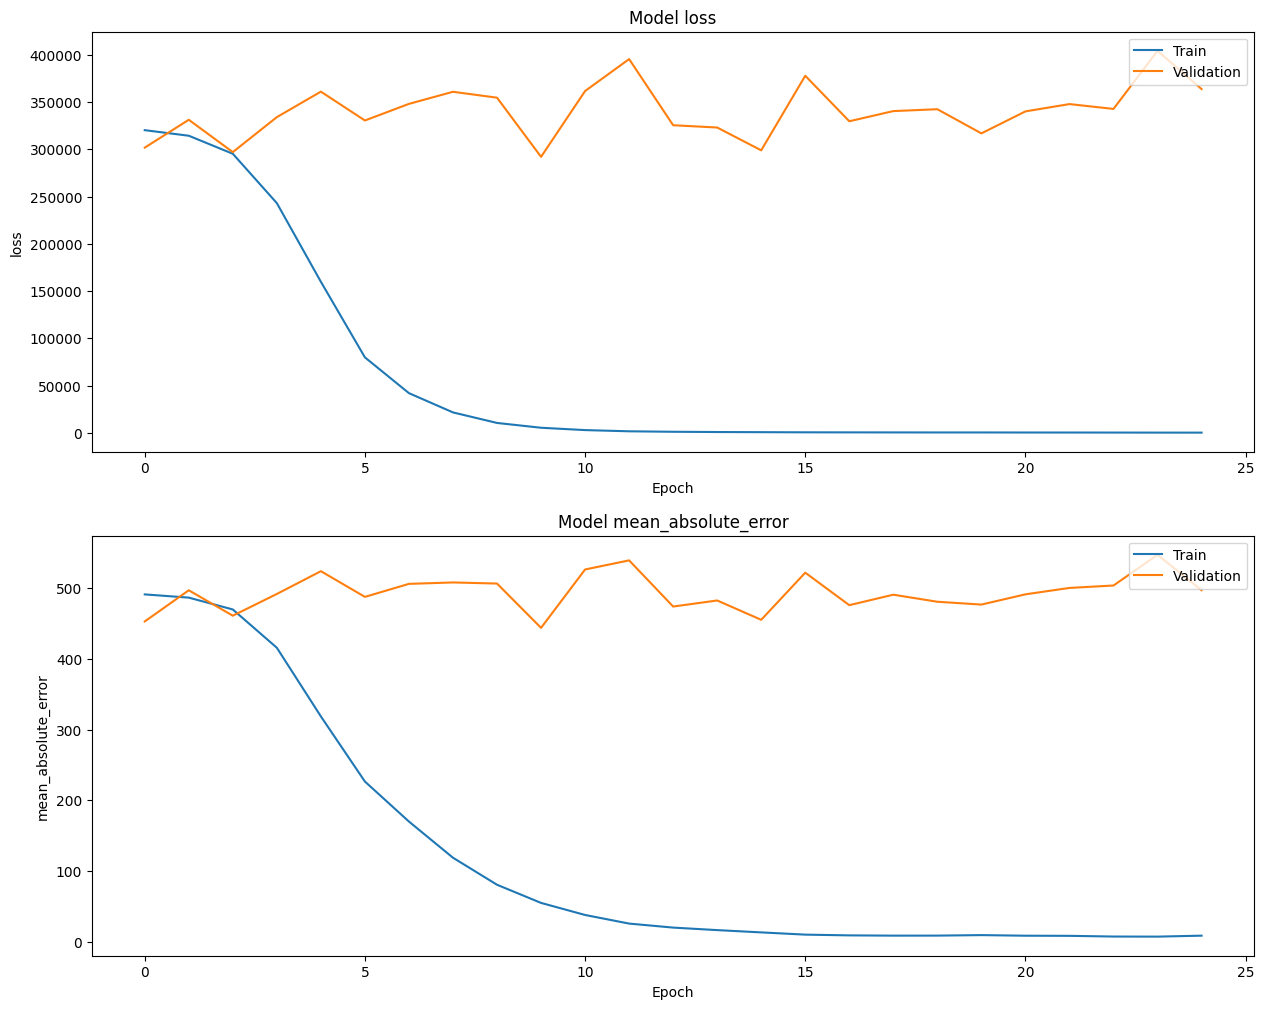

In [ ]:
plot_metrics(history, metrics=["loss"] + metrics)

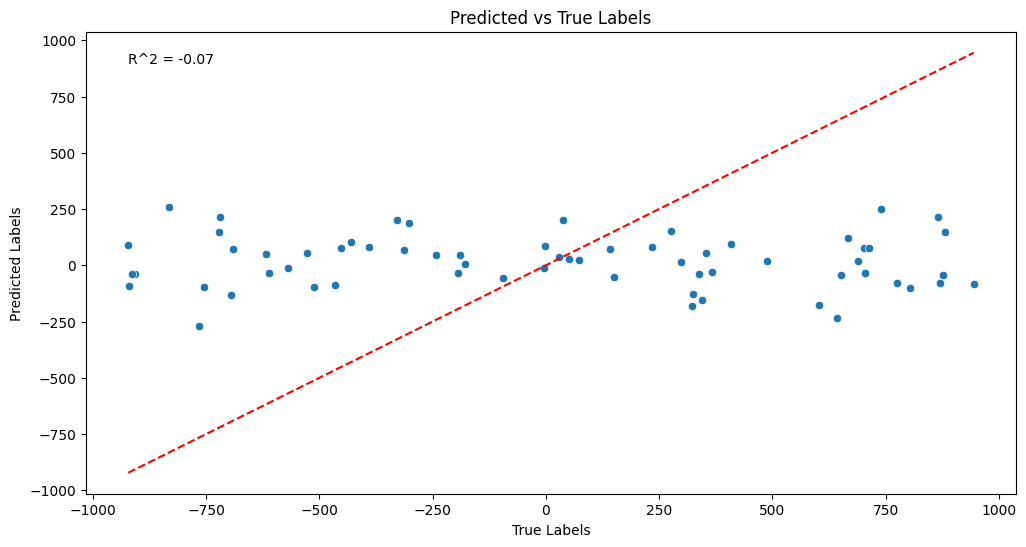

In [ ]:
plot_predictions(y_test, y_pred)

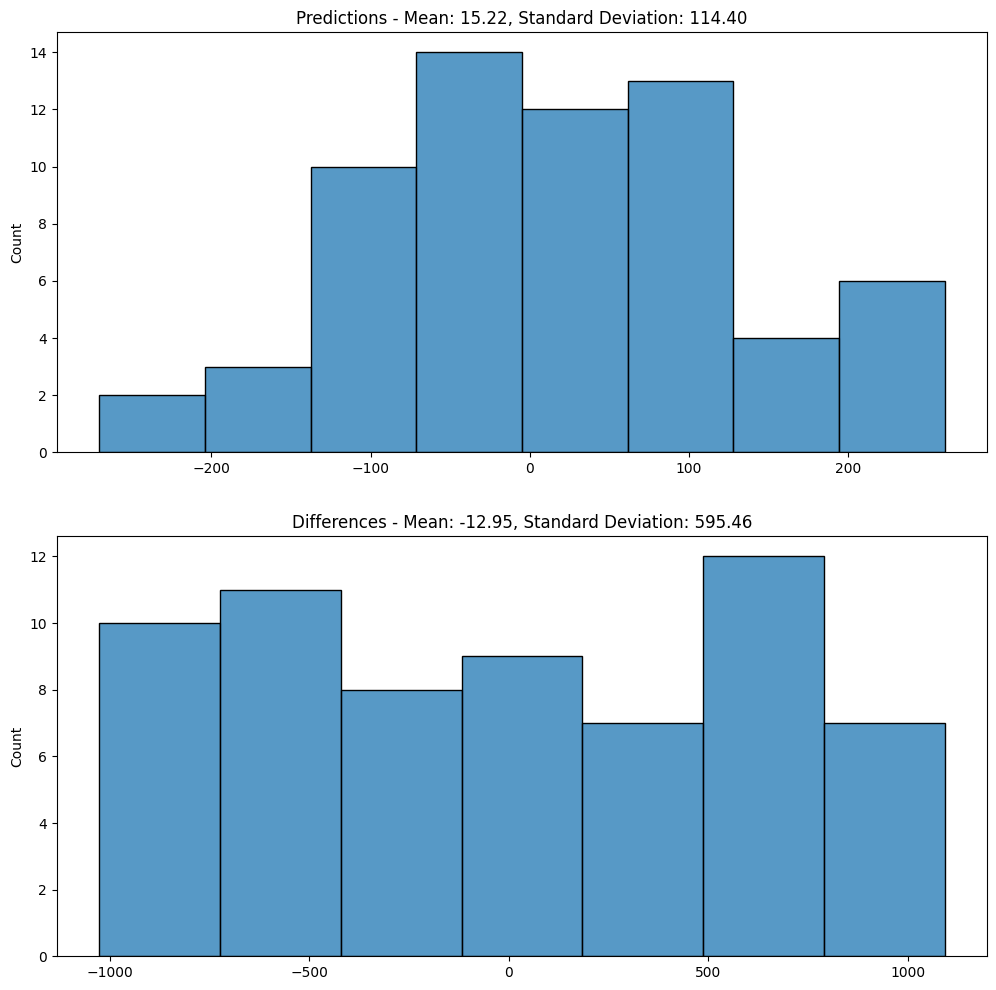

In [ ]:
plot_histogram(y_test, y_pred)